In [ ]:
import os
import glob
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as transforms
from torchvision import models

import timm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
HAIR_REMOVAL = True

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans"
})

sns.set_style("whitegrid")

Using device: cuda
GPU: Tesla T4


In [ ]:
BASE_DIR   = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
META_CSV   = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')
IMAGE_DIRS = [
    os.path.join(BASE_DIR, 'HAM10000_images_part_1'),
    os.path.join(BASE_DIR, 'HAM10000_images_part_2'),
]

df = pd.read_csv(META_CSV)

def find_image_path(image_id, dirs):
    for d in dirs:
        path = os.path.join(d, image_id + '.jpg')
        if os.path.isfile(path):
            return path
    return None

df['image_path'] = df['image_id'].apply(lambda x: find_image_path(x, IMAGE_DIRS))

df = df.dropna(subset=['image_path']).reset_index(drop=True)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['dx'])

CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)
LABEL_MAP = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

print('Label mapping:')
print(LABEL_MAP)

print('Class distribution:')
print(df['dx'].value_counts())


Label mapping:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
def remove_hair_rgb(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    inpainted = cv2.inpaint(image_bgr, mask, 1, cv2.INPAINT_TELEA)
    inpainted_rgb = cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)

    return inpainted_rgb

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
groups = df["lesion_id"]
y = df["label"]

best_split = None
best_score = float("inf")

sgkf_test = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

for train_val_idx, test_idx in sgkf_test.split(df, y, groups):
    train_val_df_temp = df.iloc[train_val_idx].reset_index(drop=True)
    test_df_temp = df.iloc[test_idx].reset_index(drop=True)

    test_pct = len(test_df_temp) / len(df) * 100

    sgkf_val = StratifiedGroupKFold(
        n_splits=9,
        shuffle=True,
        random_state=SEED
    )

    for train_idx, val_idx in sgkf_val.split(
        train_val_df_temp,
        train_val_df_temp["label"],
        train_val_df_temp["lesion_id"]
    ):
        train_df_temp = train_val_df_temp.iloc[train_idx].reset_index(drop=True)
        val_df_temp = train_val_df_temp.iloc[val_idx].reset_index(drop=True)

        train_pct = len(train_df_temp) / len(df) * 100
        val_pct = len(val_df_temp) / len(df) * 100

        test_ok = test_pct >= 10.0
        val_ok = val_pct >= 10.0

        if test_ok and val_ok:
            score = abs(test_pct - 10.0) + abs(val_pct - 10.0)

            if score < best_score:
                best_score = score
                best_split = (
                    train_df_temp.copy(),
                    val_df_temp.copy(),
                    test_df_temp.copy(),
                    train_pct,
                    val_pct,
                    test_pct
                )
train_df, val_df, test_df, train_pct, val_pct, test_pct = best_split

print("Split sizes:")
print("Train:", len(train_df), f"({train_pct:.2f}%)")
print("Validation:", len(val_df), f"({val_pct:.2f}%)")
print("Test:", len(test_df), f"({test_pct:.2f}%)")

Split sizes:
Train: 8003 (79.91%)
Validation: 1004 (10.02%)
Test: 1008 (10.06%)


In [ ]:
class HAMImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, apply_hair_removal=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.apply_hair_removal = apply_hair_removal

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])

        image_bgr = cv2.imread(image_path)

        if image_bgr is None:
            raise FileNotFoundError(f"Image not found: {image_path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        if self.apply_hair_removal:
            image_rgb = remove_hair_rgb(image_rgb)

        image_pil = Image.fromarray(image_rgb)

        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            image_tensor = transforms.ToTensor()(image_pil)

        label = torch.tensor(label, dtype=torch.long)

        return image_tensor, label

In [ ]:
class_counts = train_df["label"].value_counts().sort_index().values

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass weights:")
for class_name, weight in zip(CLASS_NAMES, CLASS_WEIGHTS.cpu().numpy()):
    print(f"{class_name}: {weight:.4f}")

CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)


Class weights:
akiec: 0.8810
bcc: 0.5902
bkl: 0.2689
df: 2.7863
mel: 0.2701
nv: 0.0448
vasc: 2.1587


In [ ]:
train_dataset = HAMImageDataset(
    train_df,
    transform=train_transform,
    apply_hair_removal=HAIR_REMOVAL
)

val_dataset = HAMImageDataset(
    val_df,
    transform=val_test_transform,
    apply_hair_removal=HAIR_REMOVAL
)

test_dataset = HAMImageDataset(
    test_df,
    transform=val_test_transform,
    apply_hair_removal=HAIR_REMOVAL
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])


In [ ]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

In [ ]:
@torch.no_grad()
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy, np.array(all_predictions), np.array(all_labels)

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=30,
    learning_rate=1e-4
):
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_path = "best_cnn_model.pth"

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_accuracy, _, _ = evaluate_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy * 100:.2f}%"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print("Best CNN model saved.")

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)

    return history

***Same for All***

In [ ]:
weights = models.ResNet50_Weights.IMAGENET1K_V2

model = models.resnet50(weights=weights)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(DEVICE)

model_label = "ResNet50"

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s] 


In [ ]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=CRITERION,
    device=DEVICE,
    num_epochs=30,
    learning_rate=1e-4
)

Epoch [1/30] Train Loss: 1.4719 | Train Accuracy: 57.47% | Val Loss: 0.9793 | Val Accuracy: 65.44%
Best CNN model saved.
Epoch [2/30] Train Loss: 1.0955 | Train Accuracy: 61.21% | Val Loss: 0.9156 | Val Accuracy: 66.43%
Best CNN model saved.
Epoch [3/30] Train Loss: 0.9540 | Train Accuracy: 65.19% | Val Loss: 0.8322 | Val Accuracy: 69.42%
Best CNN model saved.
Epoch [4/30] Train Loss: 0.8591 | Train Accuracy: 67.00% | Val Loss: 0.7660 | Val Accuracy: 70.12%
Best CNN model saved.
Epoch [5/30] Train Loss: 0.7953 | Train Accuracy: 68.74% | Val Loss: 0.6891 | Val Accuracy: 76.89%
Best CNN model saved.
Epoch [6/30] Train Loss: 0.7479 | Train Accuracy: 70.57% | Val Loss: 0.7455 | Val Accuracy: 70.62%
Epoch [7/30] Train Loss: 0.6722 | Train Accuracy: 71.96% | Val Loss: 0.6559 | Val Accuracy: 76.20%
Best CNN model saved.
Epoch [8/30] Train Loss: 0.6119 | Train Accuracy: 73.68% | Val Loss: 0.6641 | Val Accuracy: 77.19%
Epoch [9/30] Train Loss: 0.5862 | Train Accuracy: 73.93% | Val Loss: 0.6094 

Final Test Result
----------------------------------------
Test Loss: 0.5969
Test Accuracy: 78.08%

Classification Report:
              precision    recall  f1-score   support

       akiec     0.3600    0.6923    0.4737        26
         bcc     0.5143    0.8780    0.6486        41
         bkl     0.6598    0.5614    0.6066       114
          df     0.5000    0.4762    0.4878        21
         mel     0.4722    0.5050    0.4880       101
          nv     0.9430    0.8625    0.9010       691
        vasc     0.3871    0.8571    0.5333        14

    accuracy                         0.7808      1008
   macro avg     0.5481    0.6904    0.5913      1008
weighted avg     0.8144    0.7808    0.7913      1008



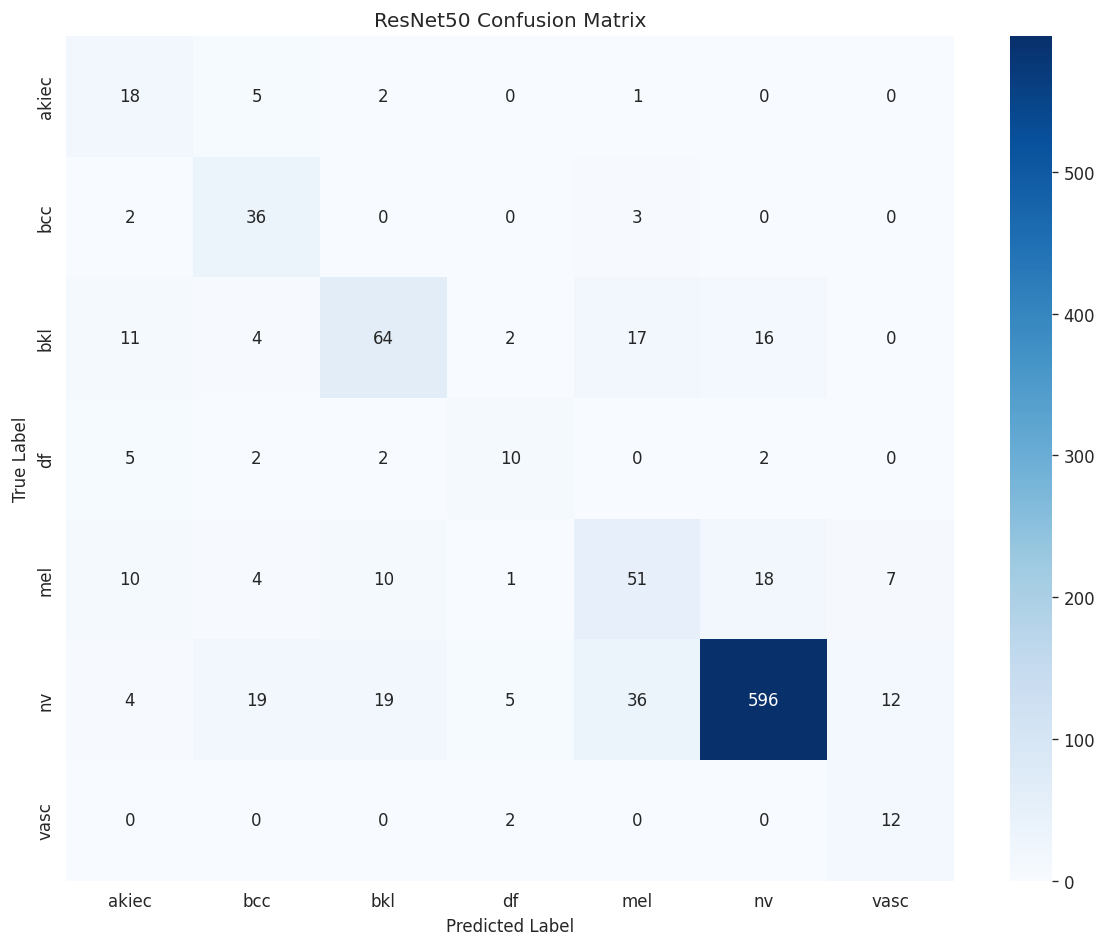

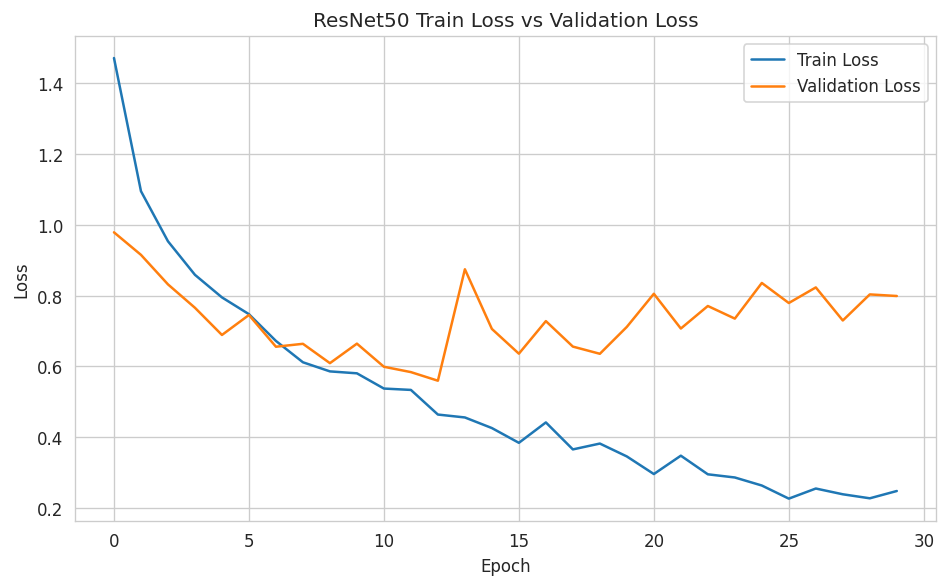

In [ ]:
test_loss, test_accuracy, test_predictions, test_labels = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=CRITERION,
    device=DEVICE
)

print("Final Test Result")
print("-" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

conf_matrix = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Train Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()